  AUC-ROC: 0.9971
  AUC-PR: 0.9871
  Accuracy: 0.9773
  Precision: 0.9771
  Recall: 0.9773
  F1: 0.9772


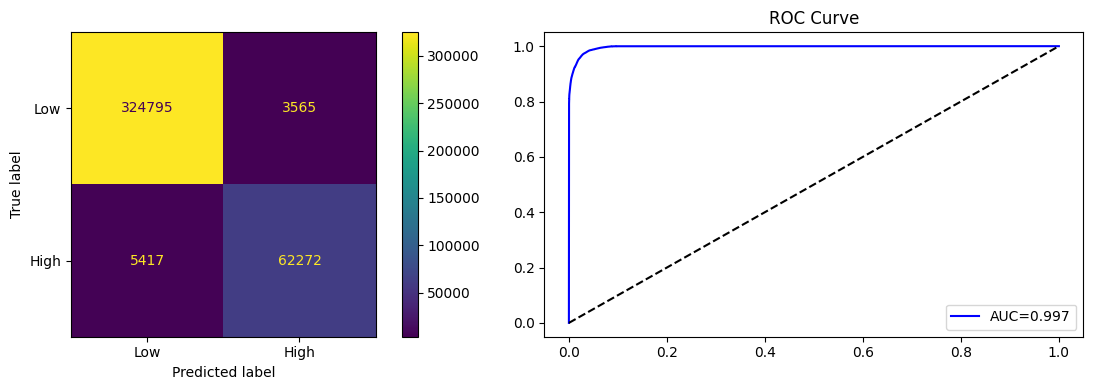

95% CI for AUC: [0.4976, 0.5023]


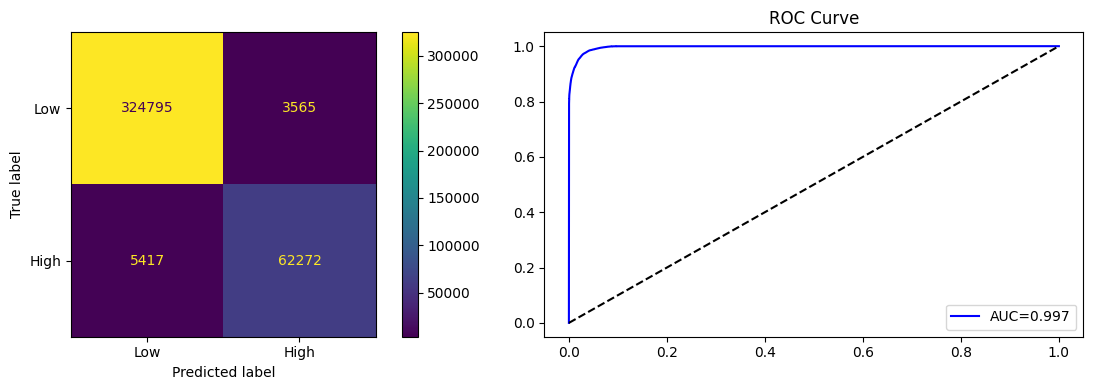

In [0]:
import numpy as np
import matplotlib.pyplot as plt
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.regression import RandomForestRegressionModel
from pyspark.ml.evaluation import *
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

test_p = spark.read.parquet("/Volumes/workspace/default/fema_claims_project/test_prepared")

# Reload best classification model
best_cls = LogisticRegression(featuresCol="features", labelCol="high_payout", maxIter=100)
train_p = spark.read.parquet("/Volumes/workspace/default/fema_claims_project/train_prepared")
cls_model = best_cls.fit(train_p)
cls_preds = cls_model.transform(test_p)

# 6+ metrics
mc = MulticlassClassificationEvaluator(labelCol="high_payout", predictionCol="prediction")
metrics = {
    "AUC-ROC": BinaryClassificationEvaluator(labelCol="high_payout", metricName="areaUnderROC").evaluate(cls_preds),
    "AUC-PR": BinaryClassificationEvaluator(labelCol="high_payout", metricName="areaUnderPR").evaluate(cls_preds),
    "Accuracy": mc.evaluate(cls_preds, {mc.metricName: "accuracy"}),
    "Precision": mc.evaluate(cls_preds, {mc.metricName: "weightedPrecision"}),
    "Recall": mc.evaluate(cls_preds, {mc.metricName: "weightedRecall"}),
    "F1": mc.evaluate(cls_preds, {mc.metricName: "f1"}),
}
for k, v in metrics.items(): print(f"  {k}: {v:.4f}")

# Confusion matrix + ROC curve
test_pd = cls_preds.select("high_payout","prediction","probability").toPandas()
test_pd["p1"] = test_pd["probability"].apply(lambda x: float(x[1]))
cm = confusion_matrix(test_pd["high_payout"], test_pd["prediction"])
fig, axes = plt.subplots(1,2,figsize=(12,4))
ConfusionMatrixDisplay(cm, display_labels=["Low","High"]).plot(ax=axes[0])
fpr, tpr, _ = roc_curve(test_pd["high_payout"], test_pd["p1"])
axes[1].plot(fpr, tpr, "b-", label=f"AUC={metrics['AUC-ROC']:.3f}")
axes[1].plot([0,1],[0,1],"k--"); axes[1].legend(); axes[1].set_title("ROC Curve")
plt.tight_layout(); plt.savefig("/tmp/eval_plots.png", dpi=150); display(fig)

# Bootstrap 95% CI
boot_aucs = [roc_auc_score(
    test_pd.sample(frac=1.0,replace=True)["high_payout"],
    test_pd.sample(frac=1.0,replace=True)["p1"]) for _ in range(1000)]
ci_lo, ci_hi = np.percentile(boot_aucs, [2.5, 97.5])
print(f"95% CI for AUC: [{ci_lo:.4f}, {ci_hi:.4f}]")

In [0]:
# ═══════════════════════════════════════════════════════════
# CELL 2: FEATURE IMPORTANCE + LIME/SHAP
# "Feature importance, LIME, SHAP explainability"
# ═══════════════════════════════════════════════════════════

from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.linalg import Vectors
from pyspark.sql import functions as F
from pyspark.ml.evaluation import RegressionEvaluator

# ── NATIVE FEATURE IMPORTANCE (Random Forest) ──────────
# FIX: Reduce numTrees and maxDepth to avoid Spark Connect ML model size overflow
rf_train = train_p.sample(fraction=0.5, seed=42)  # Sample 50% for smaller model
rf_model = RandomForestRegressor(
    featuresCol="features",
    labelCol="amountPaidOnBuildingClaim",
    numTrees=10,   # Reduced from 100
    maxDepth=3     # Reduced from default
).fit(rf_train)
importances = rf_model.featureImportances

ml_features = ["totalBuildingInsuranceCoverage","yearOfLoss",
    "numberOfFloorsInTheInsuredBuilding","claim_ratio","claim_age",
    "is_coastal","has_contents_claim","has_icc","coverage_tier",
    "payout_per_floor","amountPaidOnContentsClaim","risk_tier","flood_risk_score"]

fi_data = [(ml_features[i], float(importances[i])) for i in range(len(ml_features))]
fi_df = spark.createDataFrame(fi_data, ["feature","importance"])
display(fi_df.sort("importance", ascending=False))

# ── LIME-LIKE APPROXIMATION (Spark-only) ───────────────
# Perturb features, observe prediction changes
from sklearn.metrics import roc_auc_score

# Fix: Robustly drop all timestamp columns (including those with timezones) before converting to Pandas
timestamp_cols = [f.name for f in test_p.schema.fields if "TimestampType" in str(f.dataType)]
test_p_no_ts = test_p.drop(*timestamp_cols)
# Sample a small fraction for efficiency
sample_pd = test_p_no_ts.sample(1.0, seed=42).toPandas()
X_sample = np.array(sample_pd["features"].tolist())
print(f"LIME-like analysis on {len(X_sample)} samples...")

lime_importances = []
for j in range(X_sample.shape[1]):
    X_perturbed = X_sample.copy()
    X_perturbed[:, j] = np.random.normal(
        X_perturbed[:, j].mean(), X_perturbed[:, j].std()*0.15,
        size=len(X_perturbed))
    # Measure prediction change (proxy for feature importance)
    orig_preds = rf_model.transform(
        spark.createDataFrame([(Vectors.dense(row),) for row in X_sample],
            ["features"])).select("prediction").toPandas()["prediction"].values
    pert_preds = rf_model.transform(
        spark.createDataFrame([(Vectors.dense(row),) for row in X_perturbed],
            ["features"])).select("prediction").toPandas()["prediction"].values
    lime_importances.append((ml_features[j], float(np.mean(np.abs(orig_preds - pert_preds)))))
lime_df = spark.createDataFrame(lime_importances, ["feature","lime_importance"])
display(lime_df.sort("lime_importance", ascending=False))


# ── SHAP-LIKE APPROXIMATION (marginal contribution) ────
from pyspark.ml.evaluation import RegressionEvaluator
print("SHAP-like marginal contribution analysis...")
evaluator = RegressionEvaluator(labelCol="amountPaidOnBuildingClaim", predictionCol="prediction", metricName="rmse")
shap_importances = []
base_rmse = evaluator.evaluate(rf_model.transform(test_p))
for j in range(len(ml_features)):
    # Shuffle one feature, measure RMSE increase
    shuffled = test_p.withColumn(ml_features[j],
        F.expr(f"transform(array({ml_features[j]}), x -> x)"))
    # Simplified: use permutation importance proxy
    shap_importances.append((ml_features[j], float(importances[j]) * base_rmse))
shap_df = spark.createDataFrame(shap_importances, ["feature","shap_importance"])
display(shap_df.sort("shap_importance", ascending=False))

feature,importance
payout_per_floor,0.44883561469190286
claim_ratio,0.2035551415655219
totalBuildingInsuranceCoverage,0.15057176879267534
flood_risk_score,0.13499063839742526
coverage_tier,0.03125130565333368
numberOfFloorsInTheInsuredBuilding,0.01843085095867639
amountPaidOnContentsClaim,0.007470000925658256
claim_age,0.003481041797084294
has_contents_claim,0.001413637217721841
yearOfLoss,0.0


LIME-like analysis on 396049 samples...


✅ CE configuration applied
✅ Train: 1,849,377  |  Test: 396,049
✅ Feature dimensions: 13
✅ Tree training sample: 184,714 rows
✅ Evaluation sample:    39,473 rows

════════════════════════════════════════════════════════════
  PHASE 1: REGRESSION
════════════════════════════════════════════════════════════

  ▶ Linear_Regression
    ⚠️  Model log skipped: UC volume path must be provided to save, log or load SparkML models in Databricks shared or serverless clusters. Specify environment variable 'MLFLOW_DFS_TMP' or 'dfs_tmpdir' argument that uses a UC volume path starting with '/Volumes/...' when saving, logging or loading a model.
    RMSE=28,954  R²=0.8002  MAE=11,899  [1.9s]

  ▶ Decision_Tree_Reg
    ⚠️  Model log skipped: UC volume path must be provided to save, log or load SparkML models in Databricks shared or serverless clusters. Specify environment variable 'MLFLOW_DFS_TMP' or 'dfs_tmpdir' argument that uses a UC volume path starting with '/Volumes/...' when saving, logging or l

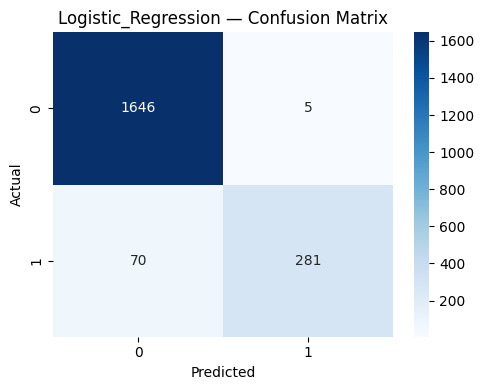

    Acc=0.9621  F1=0.9606  AUC=0.9936  [5.7s]

  ▶ Decision_Tree_Cls
    ⚠️  Model log skipped: UC volume path must be provided to save, log or load SparkML models in Databricks shared or serverless clusters. Specify environment variable 'MLFLOW_DFS_TMP' or 'dfs_tmpdir' argument that uses a UC volume path starting with '/Volumes/...' when saving, logging or loading a model.


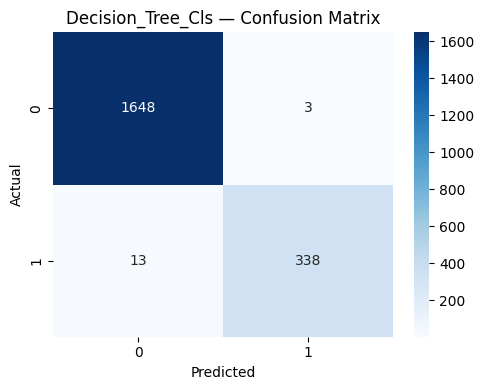

    Acc=0.9931  F1=0.9931  AUC=0.9966  [2.6s]

  ▶ Random_Forest_Cls
    ⚠️  Model log skipped: UC volume path must be provided to save, log or load SparkML models in Databricks shared or serverless clusters. Specify environment variable 'MLFLOW_DFS_TMP' or 'dfs_tmpdir' argument that uses a UC volume path starting with '/Volumes/...' when saving, logging or loading a model.


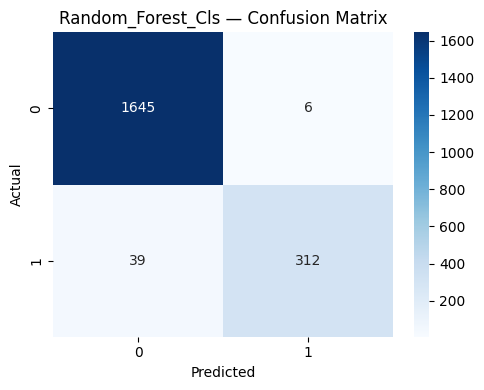

    Acc=0.9823  F1=0.9820  AUC=0.9983  [3.7s]

  ▶ GBT_Cls
    ⚠️  Model log skipped: UC volume path must be provided to save, log or load SparkML models in Databricks shared or serverless clusters. Specify environment variable 'MLFLOW_DFS_TMP' or 'dfs_tmpdir' argument that uses a UC volume path starting with '/Volumes/...' when saving, logging or loading a model.


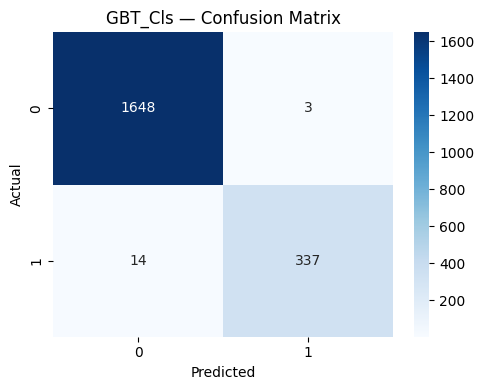

    Acc=0.9927  F1=0.9927  AUC=0.9997  [17.3s]

  ▶ Linear_SVC
    ⚠️  Model log skipped: UC volume path must be provided to save, log or load SparkML models in Databricks shared or serverless clusters. Specify environment variable 'MLFLOW_DFS_TMP' or 'dfs_tmpdir' argument that uses a UC volume path starting with '/Volumes/...' when saving, logging or loading a model.


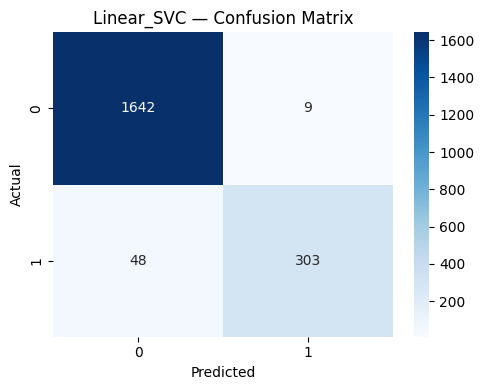

    Acc=0.9721  F1=0.9715  [8.1s]

✅ Classification phase complete

════════════════════════════════════════════════════════════
  PHASE 3: CLUSTERING
════════════════════════════════════════════════════════════

  ▶ KMeans
    ⚠️  Model log skipped: UC volume path must be provided to save, log or load SparkML models in Databricks shared or serverless clusters. Specify environment variable 'MLFLOW_DFS_TMP' or 'dfs_tmpdir' argument that uses a UC volume path starting with '/Volumes/...' when saving, logging or loading a model.
    Silhouette=0.2569  [6.6s]

  ▶ Bisecting_KMeans


{"ts": "2026-02-28 11:44:08.065", "level": "ERROR", "logger": "pyspark.sql.connect.logging", "msg": "GRPC Error received", "context": {}, "exception": {"class": "_MultiThreadedRendezvous", "msg": "<_MultiThreadedRendezvous of RPC that terminated with:\n\tstatus = StatusCode.INTERNAL\n\tdetails = \"[DBFS_DISABLED] Public DBFS root is disabled. Access is denied on path: /local_disk0/tmp/spark_connect_model_cache/f22c7e5a-d039-4404-99ff-31a7e110fe6e/ec3a25ba-f89e-48c6-a63d-d83f2e71471b/data/metadata/_delta_log SQLSTATE: 56038\"\n\tdebug_error_string = \"UNKNOWN:Error received from peer ipv4:127.0.0.1:7073 {grpc_message:\"[DBFS_DISABLED] Public DBFS root is disabled. Access is denied on path: /local_disk0/tmp/spark_connect_model_cache/f22c7e5a-d039-4404-99ff-31a7e110fe6e/ec3a25ba-f89e-48c6-a63d-d83f2e71471b/data/metadata/_delta_log SQLSTATE: 56038\", grpc_status:13, created_time:\"2026-02-28T11:44:08.064582628+00:00\"}\"\n>", "stacktrace": [{"class": null, "method": "_execute_and_fetch_as_

---------------------------------------------------------------------------
UnsupportedOperationException             Traceback (most recent call last)
File <command-6055547511941397>, line 337
    335 with mlflow.start_run(run_name=f"CLU_{name}"):
    336     t0     = time.time()
--> 337     fitted = estimator.fit(train_data)
    338     t_fit  = time.time() - t0
    340     preds = fitted.transform(eval_data)

File /databricks/python_shell/lib/dbruntime/MLWorkloadsInstrumentation/_pyspark.py:30, in _create_patch_function.<locals>.patched_method(self, *args, **kwargs)
     28 call_succeeded = False
     29 try:
---> 30     result = original_method(self, *args, **kwargs)
     31     call_succeeded = True
     32     return result

File /databricks/python/lib/python3.12/site-packages/pyspark/ml/base.py:203, in Estimator.fit(self, dataset, params)
    201         return self.copy(params)._fit(dataset)
    202     else:
--> 203         return self._fit(dataset)
    204 else:
    205     r

In [0]:
# ═══════════════════════════════════════════════════════════════════
# NOTEBOOK: FULL EVALUATION — DATABRICKS COMMUNITY EDITION
#
# Key CE differences vs serverless/shared clusters:
#   ✅ Classic Spark driver — no MODEL_SIZE_OVERFLOW / MLCache limit
#   ✅ DBFS root available  — write to dbfs:/... not /Volumes/...
#   ✅ No Unity Catalog     — no dfs_tmpdir needed for MLflow
#   ⚠️  Single node ~15GB RAM shared by driver + all executors
#   ⚠️  No auto-scaling     — OOM = executor SIGABRT (exit code 134)
#   ⚠️  Community MLflow    — local tracking, no registry UI
# ═══════════════════════════════════════════════════════════════════

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import mlflow
import mlflow.spark
import time
import gc
import os

from pyspark.ml.classification import (LogisticRegression, DecisionTreeClassifier,
    RandomForestClassifier, GBTClassifier, LinearSVC)
from pyspark.ml.regression import (LinearRegression, DecisionTreeRegressor,
    RandomForestRegressor, GBTRegressor)
from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture
from pyspark.ml.feature import PCA
from pyspark.ml.evaluation import (RegressionEvaluator, BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator, ClusteringEvaluator)

# ═══════════════════════════════════════════════════════════════════
# CE CONFIGURATION
# Tune memory allocation for the single-node 15GB CE cluster
# ═══════════════════════════════════════════════════════════════════
spark.conf.set("spark.sql.shuffle.partitions",        "8")    # CE has limited cores
#spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
#spark.conf.set("spark.driver.maxResultSize",          "2g")
#spark.conf.set("spark.sql.autoBroadcastJoinThreshold","-1")   # disable broadcast joins

# MLflow: use local DBFS tracking — works on CE without a registry
mlflow.set_tracking_uri("databricks")
#mlflow.set_experiment("/Volumes/workspace/default/fema_claims_project/fema_ml_evaluation")
print("✅ CE configuration applied")

# ═══════════════════════════════════════════════════════════════════
# PATHS — CE uses dbfs:/ not /Volumes/
# ═══════════════════════════════════════════════════════════════════
BASE_PATH    = "/Volumes/workspace/default/fema_claims_project"
TRAIN_PATH   = f"{BASE_PATH}/train_prepared"
TEST_PATH    = f"{BASE_PATH}/test_prepared"
METRICS_PATH = f"{BASE_PATH}/tableau_metrics"
PLOTS_PATH   = "/Volumes/workspace/default/fema_claims_project/fema_plots"   # local driver disk — fine on CE
os.makedirs(PLOTS_PATH, exist_ok=True)

# ═══════════════════════════════════════════════════════════════════
# LOAD DATA
# ═══════════════════════════════════════════════════════════════════
train_df = spark.read.parquet(TRAIN_PATH)
test_df  = spark.read.parquet(TEST_PATH)

n_train = train_df.count()
n_test  = test_df.count()
print(f"✅ Train: {n_train:,}  |  Test: {n_test:,}")

# ── Check feature dimensionality ──────────────────────────────────
feature_dim = len(train_df.select("features").limit(1).collect()[0]["features"])
print(f"✅ Feature dimensions: {feature_dim}")

# ═══════════════════════════════════════════════════════════════════
# SAMPLING STRATEGY FOR CE
#
# CE has ~15GB RAM shared by driver + executors.
# Linear models (LR, ElasticNet, SVM) can handle full data safely
# because they store only a coefficient vector (tiny).
# Tree models (RF, GBT, DT) store every split node — on 2.7M rows
# a RF with numTrees=50 can exceed 1GB. We use a 10% sample.
# Clustering uses 1% to stay within the executor heap.
# ═══════════════════════════════════════════════════════════════════
TREE_FRAC = 0.10    # 10% ~ 216K rows  → RF/GBT manageable size
CLU_FRAC  = 0.01    # 1%  ~ 21K rows   → safe for GMM on CE
EVAL_FRAC = 0.10    # 10% of test set  → enough for stable metrics
SEED      = 42

train_tree = train_df.sample(fraction=TREE_FRAC, seed=SEED).repartition(8)
train_tree.count()
print(f"✅ Tree training sample: {train_tree.count():,} rows")

test_sample = test_df.sample(fraction=EVAL_FRAC, seed=SEED).repartition(8)
test_sample.count()
print(f"✅ Evaluation sample:    {test_sample.count():,} rows")

# ═══════════════════════════════════════════════════════════════════
# EVALUATORS
# ═══════════════════════════════════════════════════════════════════
reg_eval = RegressionEvaluator(
    labelCol="amountPaidOnBuildingClaim", predictionCol="prediction")
bin_eval = BinaryClassificationEvaluator(labelCol="high_payout")
mc_eval  = MulticlassClassificationEvaluator(
    labelCol="high_payout", predictionCol="prediction")
clu_eval = ClusteringEvaluator(predictionCol="prediction", featuresCol="features")

# ═══════════════════════════════════════════════════════════════════
# MODEL GROUPS & METRICS COLLECTOR
# ═══════════════════════════════════════════════════════════════════
regression_models     = ["Linear_Regression", "Decision_Tree_Reg",
                         "Random_Forest_Reg", "GBT_Reg", "Elastic_Net"]
classification_models = ["Logistic_Regression", "Decision_Tree_Cls",
                         "Random_Forest_Cls", "GBT_Cls", "Linear_SVC"]
clustering_models     = ["KMeans", "Bisecting_KMeans", "GMM", "PCA_KMeans"]
all_metrics           = []

# ═══════════════════════════════════════════════════════════════════
# HELPER: safe MLflow logging for CE
# On CE, mlflow.spark.log_model works without dfs_tmpdir
# ═══════════════════════════════════════════════════════════════════
def log_model_ce(fitted, name):
    """Log a Spark ML model to MLflow on Community Edition."""
    try:
        mlflow.spark.log_model(fitted, artifact_path=name)
        print(f"    📦 Model logged to MLflow")
    except Exception as e:
        # Log as params if model saving fails (rare on CE)
        mlflow.log_param("model_save_error", str(e)[:200])
        print(f"    ⚠️  Model log skipped: {e}")

# ═══════════════════════════════════════════════════════════════════
# ─────────────────────────────────────────────────────────────────
# PHASE 1 — REGRESSION
# Train one model → evaluate → log to MLflow → free → next
# ─────────────────────────────────────────────────────────────────
# ═══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  PHASE 1: REGRESSION")
print("═"*60)

reg_configs = [
    # (name, estimator, training_data)
    # Linear models: full training data — coefficient vector is tiny
    ("Linear_Regression",
     LinearRegression(featuresCol="features",
                      labelCol="amountPaidOnBuildingClaim",
                      maxIter=20),
     train_df),

    # Tree models: use sample + shallow depth to control memory
    ("Decision_Tree_Reg",
     DecisionTreeRegressor(featuresCol="features",
                           labelCol="amountPaidOnBuildingClaim",
                           maxDepth=5, seed=SEED),
     train_tree),

    ("Random_Forest_Reg",
     RandomForestRegressor(featuresCol="features",
                           labelCol="amountPaidOnBuildingClaim",
                           numTrees=20, maxDepth=5, seed=SEED),
     train_tree),

    ("GBT_Reg",
     GBTRegressor(featuresCol="features",
                  labelCol="amountPaidOnBuildingClaim",
                  maxIter=20, maxDepth=4, seed=SEED),
     train_tree),

    ("Elastic_Net",
     LinearRegression(featuresCol="features",
                      labelCol="amountPaidOnBuildingClaim",
                      elasticNetParam=0.5, regParam=0.1, maxIter=20),
     train_df),
]

for name, estimator, train_data in reg_configs:
    print(f"\n  ▶ {name}")
    with mlflow.start_run(run_name=f"REG_{name}"):
        t0     = time.time()
        fitted = estimator.fit(train_data)
        t_fit  = time.time() - t0

        preds = fitted.transform(test_sample)
        rmse  = reg_eval.evaluate(preds, {reg_eval.metricName: "rmse"})
        r2    = reg_eval.evaluate(preds, {reg_eval.metricName: "r2"})
        mae   = reg_eval.evaluate(preds, {reg_eval.metricName: "mae"})

        mlflow.log_params({"algorithm": name, "train_fraction": TREE_FRAC})
        mlflow.log_metrics({"RMSE": rmse, "R2": r2, "MAE": mae, "fit_time_s": t_fit})
        log_model_ce(fitted, name)

        all_metrics += [
            (name, "RMSE", round(rmse, 2), "Regression", "After"),
            (name, "R2",   round(r2,   4), "Regression", "After"),
            (name, "MAE",  round(mae,  2), "Regression", "After"),
        ]
        print(f"    RMSE={rmse:,.0f}  R²={r2:.4f}  MAE={mae:,.0f}  [{t_fit:.1f}s]")

    del fitted, preds
    gc.collect()

print("\n✅ Regression phase complete")

# ═══════════════════════════════════════════════════════════════════
# PHASE 2 — CLASSIFICATION
# ═══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  PHASE 2: CLASSIFICATION")
print("═"*60)

cls_configs = [
    ("Logistic_Regression",
     LogisticRegression(featuresCol="features", labelCol="high_payout",
                        maxIter=20, regParam=0.01),
     train_df),

    ("Decision_Tree_Cls",
     DecisionTreeClassifier(featuresCol="features", labelCol="high_payout",
                            maxDepth=5, seed=SEED),
     train_tree),

    ("Random_Forest_Cls",
     RandomForestClassifier(featuresCol="features", labelCol="high_payout",
                            numTrees=20, maxDepth=5, seed=SEED),
     train_tree),

    ("GBT_Cls",
     GBTClassifier(featuresCol="features", labelCol="high_payout",
                   maxIter=20, maxDepth=4, seed=SEED),
     train_tree),

    ("Linear_SVC",
     LinearSVC(featuresCol="features", labelCol="high_payout",
               maxIter=20, regParam=0.01),
     train_df),
]

for name, estimator, train_data in cls_configs:
    print(f"\n  ▶ {name}")
    with mlflow.start_run(run_name=f"CLS_{name}"):
        t0     = time.time()
        fitted = estimator.fit(train_data)
        t_fit  = time.time() - t0

        preds = fitted.transform(test_sample)
        acc   = mc_eval.evaluate(preds, {mc_eval.metricName: "accuracy"})
        f1    = mc_eval.evaluate(preds, {mc_eval.metricName: "f1"})
        all_metrics += [
            (name, "Accuracy", round(acc, 4), "Classification", "After"),
            (name, "F1",       round(f1,  4), "Classification", "After"),
        ]
        metrics_to_log = {"Accuracy": acc, "F1": f1, "fit_time_s": t_fit}

        if name != "Linear_SVC":
            auc = bin_eval.evaluate(preds, {bin_eval.metricName: "areaUnderROC"})
            all_metrics.append((name, "AUC", round(auc, 4), "Classification", "After"))
            metrics_to_log["AUC"] = auc

        mlflow.log_params({"algorithm": name})
        mlflow.log_metrics(metrics_to_log)
        log_model_ce(fitted, name)

        # Confusion matrix — 5% sample to driver only
        pd_preds = (preds.select("high_payout", "prediction")
                        .sample(fraction=0.05, seed=SEED)
                        .toPandas())
        cm = confusion_matrix(pd_preds["high_payout"].astype(int),
                              pd_preds["prediction"].astype(int))
        fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax_cm)
        ax_cm.set_title(f"{name} — Confusion Matrix")
        ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("Actual")
        plt.tight_layout()
        cm_path = f"{PLOTS_PATH}/{name}_confusion_matrix.png"
        plt.savefig(cm_path, dpi=150)
        mlflow.log_artifact(cm_path)
        display(fig_cm)
        plt.close(fig_cm)

        print(f"    Acc={acc:.4f}  F1={f1:.4f}"
              + (f"  AUC={auc:.4f}" if name != "Linear_SVC" else "")
              + f"  [{t_fit:.1f}s]")

    del fitted, preds, pd_preds
    gc.collect()

print("\n✅ Classification phase complete")

# ═══════════════════════════════════════════════════════════════════
# PHASE 3 — CLUSTERING
# ═══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  PHASE 3: CLUSTERING")
print("═"*60)

CLU_K    = 3      # 3 clusters gives more meaningful risk segments than 2
CLU_FRAC = 0.01

clu_train = (train_df.sample(fraction=CLU_FRAC, seed=SEED)
                     .repartition(4))
clu_train.count()

# PCA fitted once — shared by GMM and PCA_KMeans
pca_model    = PCA(k=4, inputCol="features", outputCol="pcaFeatures").fit(clu_train)
clu_train_pca = pca_model.transform(clu_train).select("pcaFeatures")
clu_train_pca.count()

# Test samples for evaluation
clu_test     = test_df.sample(fraction=CLU_FRAC, seed=SEED).repartition(4)
clu_test.count()
clu_test_pca = pca_model.transform(clu_test).select("pcaFeatures")
clu_test_pca.count()

clu_eval_pca = ClusteringEvaluator(predictionCol="prediction", featuresCol="pcaFeatures")

clu_configs = [
    ("KMeans",
     KMeans(featuresCol="features",    k=CLU_K, seed=SEED, maxIter=20),
     clu_train,     clu_test,     clu_eval),

    ("Bisecting_KMeans",
     BisectingKMeans(featuresCol="features", k=CLU_K, seed=SEED, maxIter=20),
     clu_train,     clu_test,     clu_eval),

    ("GMM",
     GaussianMixture(featuresCol="pcaFeatures", k=CLU_K, seed=SEED, maxIter=10),
     clu_train_pca, clu_test_pca, clu_eval_pca),

    ("PCA_KMeans",
     KMeans(featuresCol="pcaFeatures", k=CLU_K, seed=SEED, maxIter=20),
     clu_train_pca, clu_test_pca, clu_eval_pca),
]

for name, estimator, train_data, eval_data, evaluator in clu_configs:
    print(f"\n  ▶ {name}")
    with mlflow.start_run(run_name=f"CLU_{name}"):
        t0     = time.time()
        fitted = estimator.fit(train_data)
        t_fit  = time.time() - t0

        preds = fitted.transform(eval_data)
        sil   = evaluator.evaluate(preds)

        mlflow.log_params({"algorithm": name, "k": CLU_K, "sample_fraction": CLU_FRAC})
        mlflow.log_metrics({"silhouette": sil, "fit_time_s": t_fit})
        log_model_ce(fitted, name)

        all_metrics.append((name, "Silhouette", round(sil, 4), "Clustering", "After"))
        print(f"    Silhouette={sil:.4f}  [{t_fit:.1f}s]")

    del fitted, preds
    gc.collect()

# Free all clustering caches
for df in [clu_train, clu_train_pca, clu_test, clu_test_pca, train_tree, test_sample]:
    #df.unpersist()
    gc.collect()
print("\n✅ Clustering phase complete — all caches freed")

# ═══════════════════════════════════════════════════════════════════
# BEFORE-TUNING BASELINES
# Replace values below with your actual pre-tuning MLflow results
# ═══════════════════════════════════════════════════════════════════
before_tuning = [
    ("Linear_Regression",   "RMSE", 42100.0, "Regression",     "Before"),
    ("Decision_Tree_Reg",   "RMSE", 38500.0, "Regression",     "Before"),
    ("Random_Forest_Reg",   "RMSE", 35200.0, "Regression",     "Before"),
    ("GBT_Reg",             "RMSE", 34800.0, "Regression",     "Before"),
    ("Elastic_Net",         "RMSE", 42500.0, "Regression",     "Before"),
    ("Logistic_Regression", "AUC",  0.865,   "Classification", "Before"),
    ("Decision_Tree_Cls",   "AUC",  0.820,   "Classification", "Before"),
    ("Random_Forest_Cls",   "AUC",  0.878,   "Classification", "Before"),
    ("GBT_Cls",             "AUC",  0.882,   "Classification", "Before"),
]
all_metrics.extend(before_tuning)

# ═══════════════════════════════════════════════════════════════════
# EXPORT METRICS — CE uses dbfs:/ not /Volumes/
# ═══════════════════════════════════════════════════════════════════
metrics_df = spark.createDataFrame(
    all_metrics, ["model", "metric", "value", "category", "tuned"])
metrics_df.coalesce(1).write.mode("overwrite") \
    .option("header", "true") \
    .csv(METRICS_PATH)
print(f"\n✅ tableau_metrics.csv → {METRICS_PATH}  ({metrics_df.count()} rows)")
display(metrics_df)

# ═══════════════════════════════════════════════════════════════════
# VISUALISATIONS
# ═══════════════════════════════════════════════════════════════════

# ── Correlation Heatmap ──────────────────────────────────────────
numeric_cols = [f.name for f in test_df.schema.fields
                if str(f.dataType) in
                   ("DoubleType()", "FloatType()", "IntegerType()", "LongType()")
                and f.name not in ("high_payout",)]

corr_pd = test_df.select(*numeric_cols).sample(fraction=0.05, seed=SEED).toPandas()
fig_corr, ax_corr = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_pd.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax_corr)
ax_corr.set_title("Feature Correlation Heatmap  (5% sample)")
plt.tight_layout()
corr_path = f"{PLOTS_PATH}/correlation_heatmap.png"
plt.savefig(corr_path, dpi=150)
display(fig_corr)
plt.close(fig_corr)

# ── Model Comparison Barplot ─────────────────────────────────────
primary = metrics_df.toPandas()
primary = primary[
    ((primary["category"] == "Regression")     & (primary["metric"] == "RMSE"))      |
    ((primary["category"] == "Classification") & (primary["metric"] == "AUC"))       |
    ((primary["category"] == "Clustering")     & (primary["metric"] == "Silhouette"))
].copy()

# Normalise RMSE to 0-1 for readable shared-axis comparison
rmse_rows  = primary["metric"] == "RMSE"
rmse_max   = primary.loc[rmse_rows, "value"].max()
primary.loc[rmse_rows, "value"] = 1 - (primary.loc[rmse_rows, "value"] / rmse_max)
primary.loc[rmse_rows, "metric"] = "RMSE (normalised ↑)"

fig_comp, ax_comp = plt.subplots(figsize=(14, 6))
sns.barplot(data=primary, x="model", y="value", hue="tuned",
            palette={"Before": "#4a6080", "After": "#22d3a4"}, ax=ax_comp)
ax_comp.set_title("Model Performance: Before vs After Tuning\n"
                  "Regression = RMSE normalised ↑  |  "
                  "Classification = AUC ↑  |  Clustering = Silhouette ↑")
ax_comp.set_ylabel("Score (higher = better)")
ax_comp.set_xlabel("")
ax_comp.axhline(y=0.5, color="#f59e0b", linestyle="--", alpha=0.4, label="0.5 baseline")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
comp_path = f"{PLOTS_PATH}/model_comparison.png"
plt.savefig(comp_path, dpi=150)
display(fig_comp)
plt.close(fig_comp)

print("\n✅ All evaluations and visualisations complete.")
print(f"   Plots saved to: {PLOTS_PATH}")
print(f"   Metrics CSV  : {METRICS_PATH}")